In [18]:
from dotenv import load_dotenv
import os
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
# 모델 초기화
model = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite", google_api_key=os.getenv("GEMINI_API_KEY")
)
model.invoke("안녕")

AIMessage(content=[{'type': 'text', 'text': '안녕하세요! 무엇을 도와드릴까요?', 'extras': {'signature': 'EjQKMgERTTIPjbCynnD40QxPxbRIv5p6+VixIAfmIj2wSrGFKLgmCaCwPDijii1Rbu4N0kTc'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fe640-14c8-7b62-aae1-ec84f8e57a7a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3, 'output_tokens': 8, 'total_tokens': 11, 'input_token_details': {'cache_read': 0}})

In [19]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
      messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
      'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
      (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다.)
    """

    messages: Annotated[list[str], add_messages]


# StateGraph 클래스를 사용하여 State 타입의 그래프 생성
graph_builder = StateGraph(State)

In [20]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper


# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f"{timezone} ({location}) 현재시각 {now}"
        print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"


@tool
def get_web_search(query: str, search_period: str = 'm') -> str:
    """웹 검색을 수행하는 함수.
    Args:
        query (str): 검색어
        search_period (str): 검색 기간(e.g., 'w' for past week, 'm' for past month, 'y' for past year)
    Returns:
        str: 웹 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(region="kr-kr", time=search_period)

    print("---------- WEB SEARCH ----------")
    print(query)
    print(search_period)
    print("--------------------------------")

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source='news',
        results_separator=";\n",
    )

    searched = search.invoke(query)

    for i, result in enumerate(searched.split(";\n")):
        print(f"{i+1}. {result}")

    return searched


tools = [get_current_time, get_web_search]

In [21]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "서울"})

Asia/Seoul (서울) 현재시각 2026-08-09 20:19:47


'Asia/Seoul (서울) 현재시각 2026-08-09 20:19:47'

In [22]:
tools[1].invoke({"query": "파이썬", "search_period": "m"})

---------- WEB SEARCH ----------
파이썬
m
--------------------------------
1. snippet: 코딩 까막눈 아재의 독학 4일째! 오늘은 다시 초심 (?)으로 돌아가 을 연습하기로 합니다. 글씨쓰기부터 해봐야겠어요. 일단 지금까지 공부한 내용들을 정리해 봅니다. 1. 거북이 그래픽 모듈이란? 파이썬에 기본적으로 장착된 '그림 그리기' 모듈입니다. 거북이 모양의 ..., title: 【파이썬 독학】 거북이 모듈로 글씨쓰기 (명령어 모음) : 네이버 블로그, link: https://blog.naver.com/PostView.naver?blogId=kenpa44&logNo=223097144747
2. snippet: #파이썬기초 #리스트컴프리헨션 #ListComprehension #파이썬문법 #코딩입문 #파이썬200제 #혼자공부하는파이썬 #파이썬매일코딩 #Python기초 #파이썬개발자 #코딩스킬 #개발자블로그 #파이썬팁 #효율적인코딩 #코딩공부 #코딩연습 #파이썬배우기 #Python고급문법 #프로그래밍입문 #네이버블로그팁 #파이썬문제 ..., title: [파이썬 고급] 리스트 컴프리헨션 (List Comprehension) 완벽 정리! : 네이버 블로그, link: https://blog.naver.com/brotechtalks/223855633143
3. snippet: 파이썬에서 함수를 사용할 줄 알면 같은 코드를 여러 번 작성할 필요가 없습니다.데이터 분석과 AI 개발에서도 반복 작업을 자동화할 때 가장 많이 사용하는 문법이 바로 함수(Function)입니다.이번 글에서는 함수의 기본 문법부터 실무 활용 예제까지 쉽게 알아보겠습니다. 1. 함수의 기본 구조 ..., title: [Python] 파이썬 함수(Function) 핵심 문법 | def, return, 매개변수 완벽 정리, link: https://aplus-archive.tistory.com/10
4. snippet: 고등학생부터, 파이썬 · 

'snippet: 코딩 까막눈 아재의 독학 4일째! 오늘은 다시 초심 (?)으로 돌아가 을 연습하기로 합니다. 글씨쓰기부터 해봐야겠어요. 일단 지금까지 공부한 내용들을 정리해 봅니다. 1. 거북이 그래픽 모듈이란? 파이썬에 기본적으로 장착된 \'그림 그리기\' 모듈입니다. 거북이 모양의 ..., title: 【파이썬 독학】 거북이 모듈로 글씨쓰기 (명령어 모음) : 네이버 블로그, link: https://blog.naver.com/PostView.naver?blogId=kenpa44&logNo=223097144747;\nsnippet: #파이썬기초 #리스트컴프리헨션 #ListComprehension #파이썬문법 #코딩입문 #파이썬200제 #혼자공부하는파이썬 #파이썬매일코딩 #Python기초 #파이썬개발자 #코딩스킬 #개발자블로그 #파이썬팁 #효율적인코딩 #코딩공부 #코딩연습 #파이썬배우기 #Python고급문법 #프로그래밍입문 #네이버블로그팁 #파이썬문제 ..., title: [파이썬 고급] 리스트 컴프리헨션 (List Comprehension) 완벽 정리! : 네이버 블로그, link: https://blog.naver.com/brotechtalks/223855633143;\nsnippet: 파이썬에서 함수를 사용할 줄 알면 같은 코드를 여러 번 작성할 필요가 없습니다.데이터 분석과 AI 개발에서도 반복 작업을 자동화할 때 가장 많이 사용하는 문법이 바로 함수(Function)입니다.이번 글에서는 함수의 기본 문법부터 실무 활용 예제까지 쉽게 알아보겠습니다. 1. 함수의 기본 구조 ..., title: [Python] 파이썬 함수(Function) 핵심 문법 | def, return, 매개변수 완벽 정리, link: https://aplus-archive.tistory.com/10;\nsnippet: 고등학생부터, 파이썬 · 1화프로그래밍이란? + print()와 변수파이썬이 뭔지 몰라도, 코드 한 줄 안 짜봤어도 괜찮아요. 오늘은 "프로그래밍이 무엇인지"부

In [23]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x000001300309C220>
get_web_search name='get_web_search' description="웹 검색을 수행하는 함수.\nArgs:\n    query (str): 검색어\n    search_period (str): 검색 기간(e.g., 'w' for past week, 'm' for past month, 'y' for past year)\nReturns:\n    str: 웹 검색 결과" args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x000001300309C900>


In [24]:
model_with_tools = model.bind_tools(tools)  # GENAI 언어 모델에 도구 연결


def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환 값:
    dict: 모델이 생성한 응답 메시지를 포함한 딕셔너리
        형식은 {'messages':[응답 메시지]} 입니다.
    """
    return {"messages": model_with_tools.invoke(state["messages"])}


graph_builder.add_node("generate", generate)

In [25]:
import json
from langchain_core.messages import ToolMessage


class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessages에서 요청된 도구를 실행합니다.
    Attributes:
      tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
      __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
      __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """

    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:  # 1
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):  # 2
        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트 가져오기
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:  # 3
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )

        return {"messages": messages + outputs}


tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [26]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """

    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END


graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate", route_tools, {"tools": "tools", END: END}
)

# 도구가 호출될 때 마다 다음 단계를 결정하기 위해 챗봇으로 돌아감.
graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()

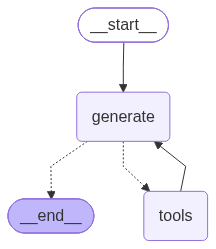

In [27]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [28]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇 시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end="")

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

gathered

[][][]Asia/Seoul (Seoul) 현재시각 2026-08-09 20:19:52
[{'type': 'text', 'text': '현재 서울', 'index': 0}][{'type': 'text', 'text': '의 시간은 2026년 8월 9일 일', 'index': 0}][{'type': 'text', 'text': '요일 오후 8시 19분입니다.', 'index': 0}][{'type': 'text', 'text': '', 'extras': {'signature': 'EjQKMgERTTIPagzrIVZFaRoZu1ve0WAk4etKPisJ8D11Yt6M1YmNuLXIMe41ankelG7ZPc+O'}, 'index': 0}][]

AIMessageChunk(content=[{'type': 'text', 'text': '현재 서울의 시간은 2026년 8월 9일 일요일 오후 8시 19분입니다.', 'index': 0, 'extras': {'signature': 'EjQKMgERTTIPagzrIVZFaRoZu1ve0WAk4etKPisJ8D11Yt6M1YmNuLXIMe41ankelG7ZPc+O'}}], additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"location": "Seoul", "timezone": "Asia/Seoul"}'}, '__gemini_function_call_thought_signatures__': {'bcbAXtc0': 'EjQKMgERTTIP1d440WSWlKW540UdSFzpDvTguiaXrB4HRreoRcc6KTx/XgFoTnK/ES/acILx'}}, response_metadata={'safety_ratings': [], 'model_provider': 'google_genai', 'finish_reason': 'STOPSTOP', 'model_name': 'gemini-3.1-flash-litegemini-3.1-flash-lite'}, id='lc_run--019fe640-2692-7cd3-bf68-07b28c430367', tool_calls=[{'name': 'get_current_time', 'args': {'location': 'Seoul', 'timezone': 'Asia/Seoul'}, 'id': 'bcbAXtc0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 430, 'output_tokens': 55, 'total_tokens': 485, 'input_token_details': {'cache_read': 0}}, tool_call_chunks=[{'name

In [30]:
from langchain_core.messages import AIMessageChunk, SystemMessage, HumanMessage

about = "서울 월드컵 경기장 잔디 문제"

inputs = [
    SystemMessage(
        content="너는 조선일보의 심층 분석 전문 기자이다. 독자들이 흥미를 가질 만한 사실적인 기사를 작성한다."
    ),
    HumanMessage(
        content=f"""
최근 '{about}'에 대한 비판 기사를 작성하려고 합니다.

1. 먼저 웹 검색 도구를 사용해 최근 서울 월드컵 경기장 잔디 문제와 관련해 어떤 논란과 이슈가 있었는지 최신 정보를 검색하세요.
2. 검색된 사실과 구체적인 수치/사례들을 바탕으로 최종 비판 기사를 작성해 주세요.

기사는 반드시 아래 형식을 갖추어야 합니다:
- **[제목]**: 독자의 눈길을 끄는 강력한 제목
- **[부제]**: 기사 내용을 요약하는 서브 타이틀
- **[리드문]**: 사건의 핵심을 짚는 서두
- **[본문]**: 구체적 논란, 원인 분석, 비판 등을 깊이 있게 다룬 본문
"""
    )
]

# 실행 및 텍스트만 실시간 파싱하여 출력
for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        # 1. content가 일반 문자열인 경우
        if isinstance(msg.content, str):
            print(msg.content, end="")
        # 2. content가 Gemini 특유의 리스트 구조인 경우
        elif isinstance(msg.content, list):
            for item in msg.content:
                if isinstance(item, dict) and "text" in item:
                    print(item["text"], end="")
                elif isinstance(item, str):
                    print(item, end="")


---------- WEB SEARCH ----------
서울 월드컵 경기장 잔디 논란 최신 이슈
m
--------------------------------
1. snippet: 2026 북중미월드컵 결승전이 열릴 예정인 경기장에 깔린 잔디밭 조각을 450달러 (67만원)에 팔겠다고 나선 국제축구연맹 (FIFA·피파)를 두고 '과도한 ..., title: 월드컵 잔디 '한 조각 67만원' 배송…"Fifa 탐욕의 굿즈" 논란, link: https://www.hani.co.kr/arti/international/international_general/1268050.html
2. snippet: 국제축구연맹 피파 공식 스토어 등에서 판매된 결승전 경기장 잔디 조각입니다. 한국 시각으로 오는 20일 스페인과 아르헨티나의 북중미 월드컵 결승전이 열릴 미국 뉴저지 메트라이프 스타디움 잔디를 실제로 떠내 최고급 아크릴 케이스에 영구 보존한 한정판 기념품이라는데요. 가장 저렴한 기본 제품은 450달러 우리 돈으로 60만 원이 넘고요. 최고급 구성을 갖춘 제품은 3천 달러에 달하는데요. 결승전이 끝난 뒤에야 제품을 제작하고 미국과 영국, 유럽 지역에서만 배송 받을 수 있음에도 기본 제품은 이미 매진됐다고 합니다., title: 한 조각에 67만원…Fifa, '경기장 잔디' 기념품 논란 [잇슈 Sns], link: https://news.kbs.co.kr/news/pc/view/view.do?ncd=8612214
3. snippet: 과도한 상업화로 비판을 받아온 2026 북중미 월드컵에서, 이번에는 경기장 잔디까지 공식 기념품으로 등장해 화제를 모으고 있습니다. FIFA 공식 스토어는 최근 '2026 월드컵 경기장 조각'이라는 새로운 상품을 등록하고 예약 판매를 시작했습니다. 최고급 아크릴 케이스에 결승전 경기장의 실제 잔디 조각을 영구 보존한 이 상품의 가격은 450달러, 우리 돈으로 약 67만 원에 달합니다. FIFA 측은 세계 최고의 스포츠 행사를 기념하는 특별한